# Memory Management

---

Consider a case where you have requested 2 executors, each with 512 MB memory and 4 cores. Now it's the duty of the Resource Manager to go ahead and allocate all of this on the worker node. Your cluster runs on the worker nodes, so consider there are 2 worker nodes — Worker 1 and Worker 2. Once you request for an executor, a JVM process is created in the worker node with the same memory you requested. So we requested 2 executors, so 2 JVM processes get created in each of the worker nodes. Now the memory would be around 512 MB each.

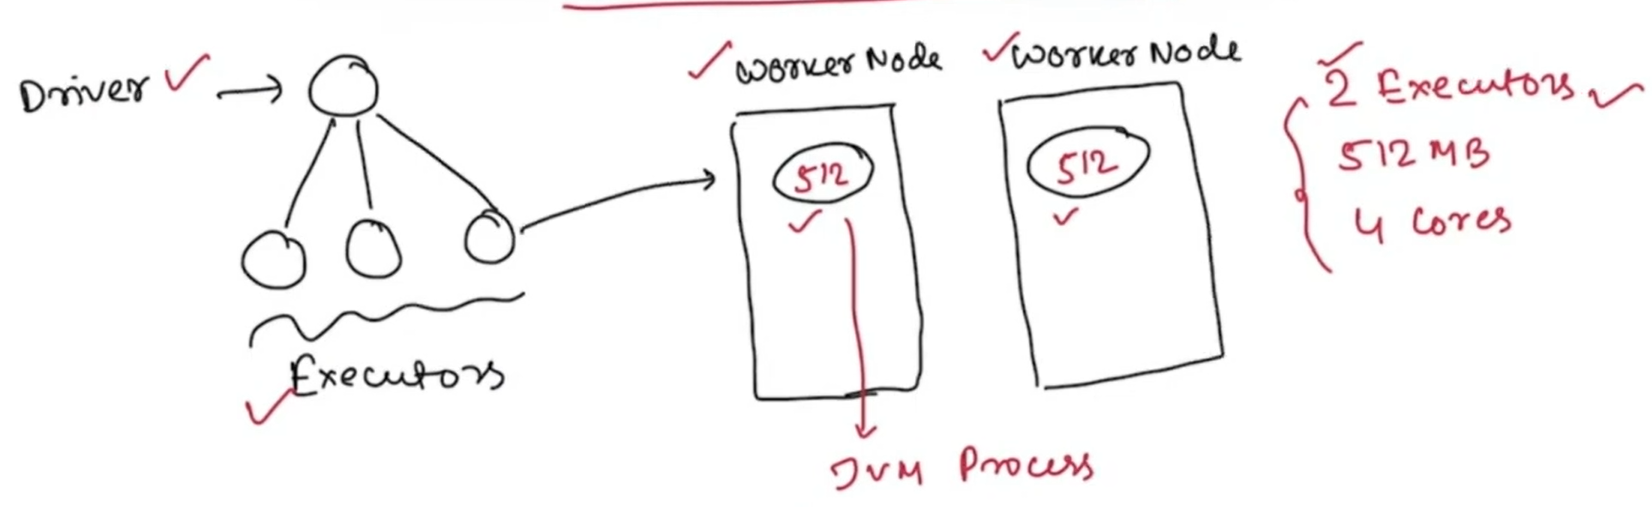

So the memory of these JVM processes is called the **JVM Heap**. There are 2 types of JVM Heap:

---

1. **ON HEAP** (Default memory)

2. **OFF HEAP** (managed by OS) — disabled by default

ON HEAP is managed by the JVM itself.

If you want to use OFF HEAP, we first need to enable it.

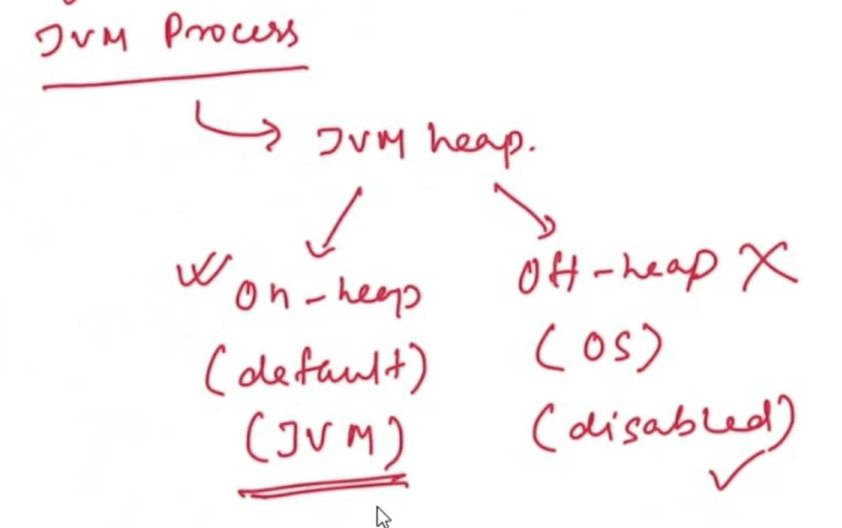

So once we request for 512 MB memory, this ON HEAP will be the one that will be generated.

---

The JVM will not directly give the 512 MB — it will only give 89% of that. The rest 11% will be used by the JVM in-house processes like Garbage Collection.

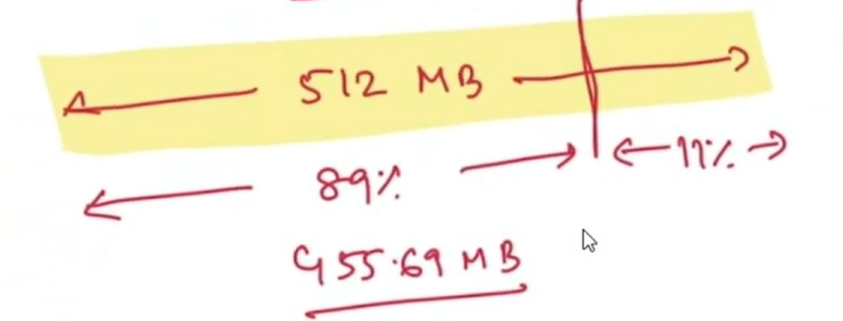

So we can only use the 89% of 512 MB, that is 455.69 MB.

---

We can't directly use all that 455.69 MB because Spark will keep 300 MB as a **Reserved Memory** for Spark internals. The rest 155.69 MB can be used further.

We can't use that 155.69 MB fully because it's a 60% : 40% ratio.

- 60% is the **Unified Spark Memory**
- 40% is the **User Memory**

Here 60% is 93.4 MB memory and 40% is 62.28 MB memory.

---

The minimum amount of memory that we can request is 1.5x of the Reserved Memory. That is 1.5 × 300 = 450 MB.

It means we cannot create any executor with memory less than 450 MB.

---

Spark Memory is completely used by Spark and has 100% control on it.

User Memory is the one that Spark doesn't have any control over — mainly used to store user data structures and UDFs.

---

Unified Spark Memory has 2 portions:

1. **Storage** — used to cache our data

2. **Execution** — holds all of the data required for execution

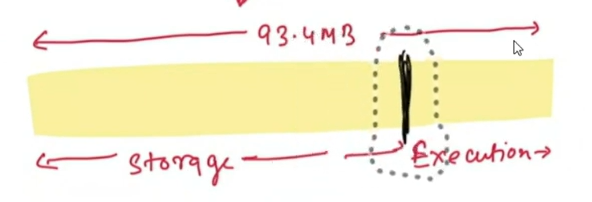

The boundary between them is not a hard boundary. This can be shifted according to the requirement.

---

Consider we cached some data — all that data will go to the Storage Memory. So if it requires some more memory, then it will consume some from the Execution side if it's free.

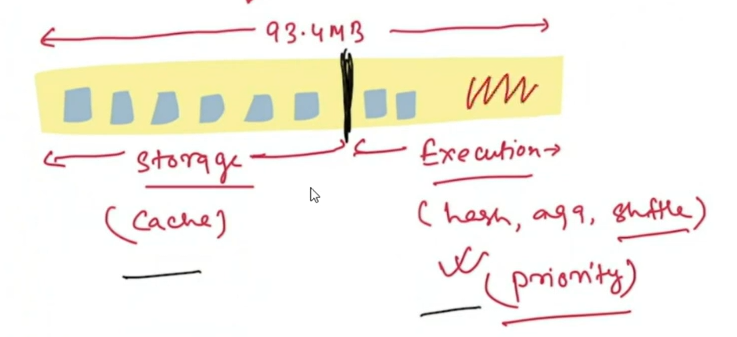

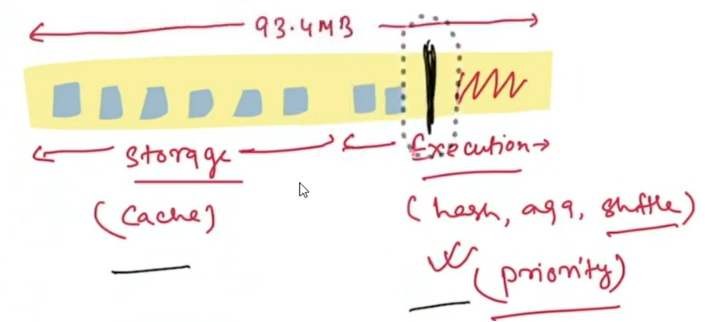

---

Now consider Execution Memory grows and it requires more memory, so it will try to claim back its space. The Storage has to evict the space it consumed based on **LRU (Least Recently Used)** mechanism.

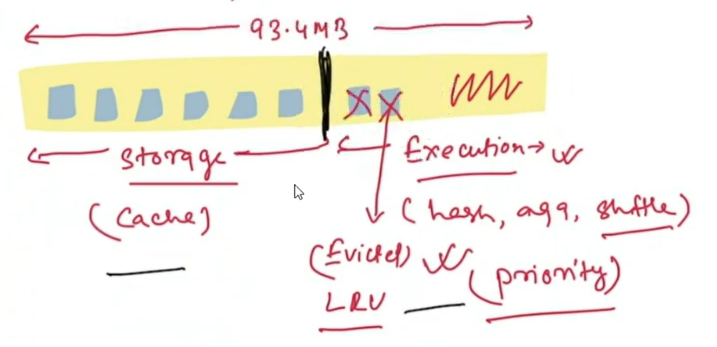

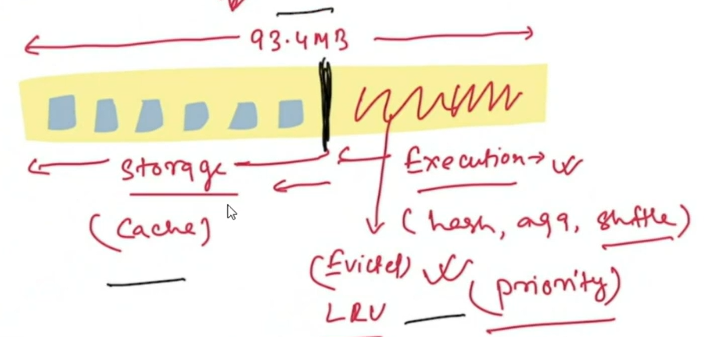

Execution can also consume more memory from Storage if required, if it's free. If it's not free, it can only consume up to 50% of the Unified Memory (`spark.memory.storageFraction`).

---

Execution has more priority. For example, Execution is consuming around 70% and only 30% is right now used by Storage. But Storage now needs more memory — like if it needs 20% more memory, it can't do it until Execution is completed.

---

## Spilling of Data to Disk

---

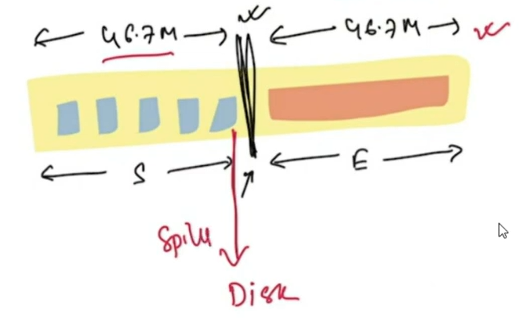

If the Storage is not enough, then it will spill the data to disk. Spillage will only happen if the caching mechanism is defined as **memory and disk** (in this case serialization and deserialization will happen).

Deserialized format is the Java objects. When it is spilled to disk, it will get serialized — that is, it will be converted to byte strings.

---

Spill will also happen in Execution:

Execution Memory is used by the cores. The whole Execution Memory will be split into equal 4 divisions — if total is 40 MB then 10 MB each.

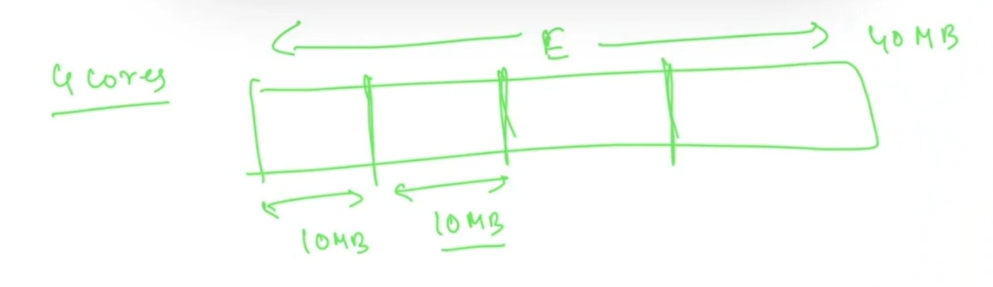

---

If we have 2 executors with 20 MB, we are processing 2 data:

1. 25 MB

2. 5 MB

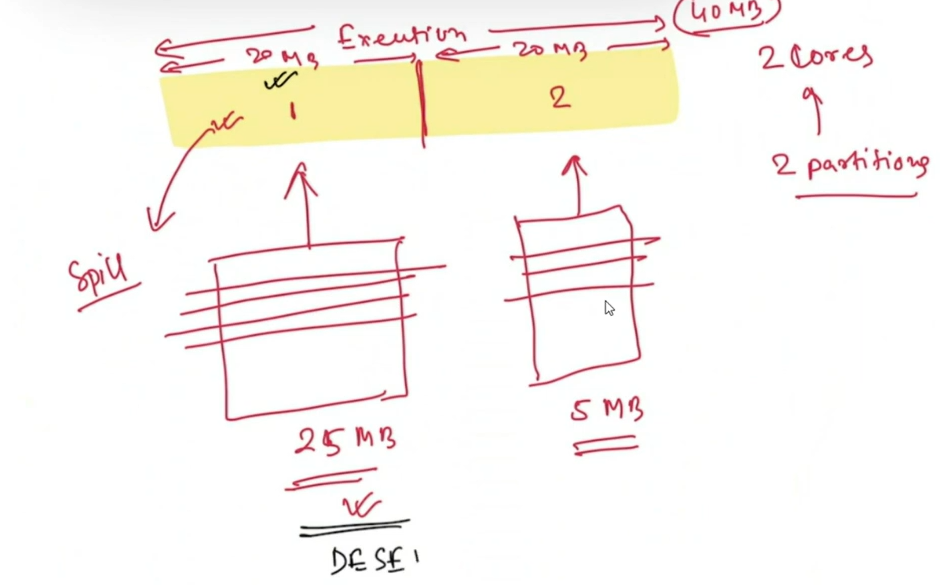

So 5 out of 25 MB will be spilled to disk — from deserialized to serialized format.

---

Consider if the record on the partition — each one of them is bigger than 20 MB.

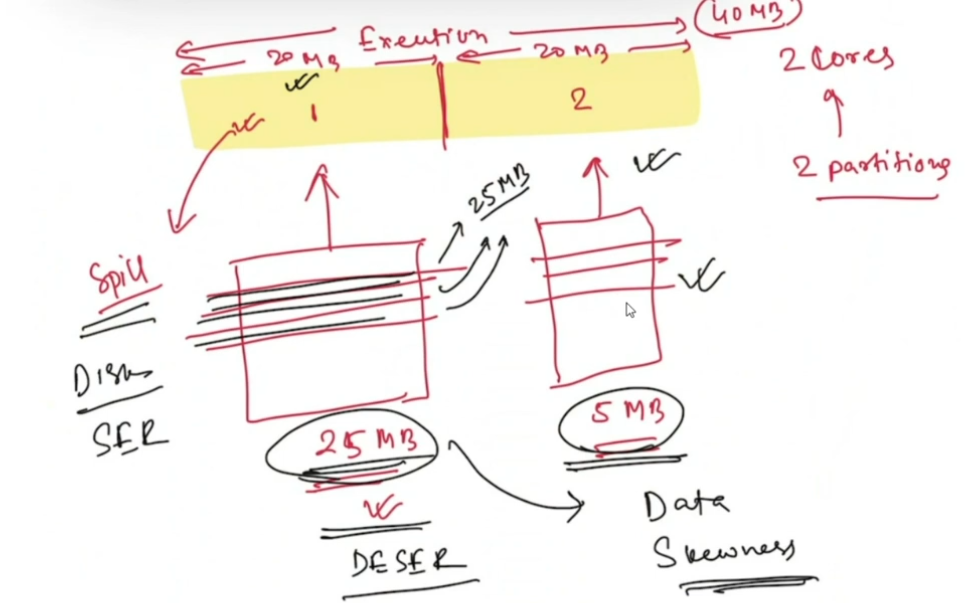

This will lead to an **Out Of Memory** error. The same will happen with some `explode` operations.

---

## OFF HEAP Memory

`spark.memory.offHeap.enabled` ⟹ `true`

`spark.memory.offHeap.size` ⟹ `512mb` (set the size)

Instead of spilling to storage, now we can spill to Off Heap.

But the limitation is that now the Garbage Collection needs to be handled.

---